<a href="https://colab.research.google.com/github/SnazzyBeatle115/UG54/blob/main/chapters/Finance/Performance_evaluation_c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Performance Evaluation

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Frame performance through risk-adjusted metrics** — Distinguish raw returns from Sharpe ratio and alpha
2. **Run an alpha test with the CAPM** — Subtract RF, regress on market, interpret $\alpha$, $\beta$, t-stats
3. **Quantify estimation error** — Compute standard errors, confidence bands, and bootstrap Sharpe ratios
4. **Diagnose over-fitting** — Understand how data-mining inflates t-stats and practice safeguards
5. **Design robust backtests** — Build hold-out periods, cross-validation splits, and rolling windows
6. **Combine strategies intelligently** — Estimate optimal weights in one subsample, validate in another
7. **Detect publication bias** — Compare pre- and post-publication performance of famous anomalies
8. **Translate diagnostics into sizing** — Use a calibrated discovery process to accept, size, or discard strategies

## 📋 Table of Contents

1. [Alpha Testing: The Pod Manager Problem](#alpha-testing)
2. [MVE Example: Overfitting in Action](#mve-example)
3. [Building a Diagnostics Toolkit](#diagnostics-toolkit)
4. [Adjusting for Multiple Testing](#multiple-testing)
5. [Sample Splitting Strategies](#sample-splitting)
6. [Publication Bias](#publication-bias)
7. [Exercises](#exercises)
8. [Key Takeaways](#key-takeaways)

---

## 🛠️ Setup

In [27]:
#@title 🛠️ Setup: Run this cell first (click to expand)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sm
import pandas_datareader.data as web
from scipy.stats import norm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

def get_factors(factors='CAPM', freq='daily'):
    if freq == 'monthly':
        freq_label = ''
    else:
        freq_label = '_' + freq

    if factors == 'CAPM':
        fama_french = web.DataReader("F-F_Research_Data_Factors" + freq_label, "famafrench", start="1921-01-01")
        df_factor = fama_french[0][['RF', 'Mkt-RF']]
    elif factors == 'FF3':
        fama_french = web.DataReader("F-F_Research_Data_Factors" + freq_label, "famafrench", start="1921-01-01")
        df_factor = fama_french[0][['RF', 'Mkt-RF', 'SMB', 'HML']]
    elif factors == 'FF5':
        fama_french = web.DataReader("F-F_Research_Data_Factors" + freq_label, "famafrench", start="1921-01-01")
        df_factor = fama_french[0][['RF', 'Mkt-RF', 'SMB', 'HML']]
        fama_french2 = web.DataReader("F-F_Research_Data_5_Factors_2x3" + freq_label, "famafrench", start="1921-01-01")
        df_factor = df_factor.merge(fama_french2[0][['RMW', 'CMA']], on='Date', how='outer')
    else:
        fama_french = web.DataReader("F-F_Research_Data_Factors" + freq_label, "famafrench", start="1921-01-01")
        df_factor = fama_french[0][['RF', 'Mkt-RF', 'SMB', 'HML']]
        fama_french2 = web.DataReader("F-F_Research_Data_5_Factors_2x3" + freq_label, "famafrench", start="1921-01-01")
        df_factor = df_factor.merge(fama_french2[0][['RMW', 'CMA']], on='Date', how='outer')
        fama_french3 = web.DataReader("F-F_Momentum_Factor" + freq_label, "famafrench", start="1921-01-01")
        df_factor = df_factor.merge(fama_french3[0], on='Date')
        df_factor.columns = ['RF', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']

    if freq == 'monthly':
        df_factor.index = pd.to_datetime(df_factor.index.to_timestamp())
    else:
        df_factor.index = pd.to_datetime(df_factor.index)

    return df_factor / 100

# Load Fama-French 6-factor data (monthly)
df_ff6 = get_factors('ff6', freq='monthly').dropna()
print(f"Sample: {df_ff6.index[0].strftime('%Y-%m')} to {df_ff6.index[-1].strftime('%Y-%m')} ({len(df_ff6)} months)")
df_ff6.head()

Sample: 1963-07 to 2026-02 (752 months)


,RF,Mkt-RF,SMB,HML,RMW,CMA,MOM
Date,,,,,,,
1963-07-01,0.0027,-0.0039,-0.0057,-0.0081,0.0064,-0.0115,0.0101
1963-08-01,0.0025,0.0508,-0.0095,0.0170,0.0040,-0.0038,0.0100
1963-09-01,0.0027,-0.0157,-0.0025,0.0000,-0.0078,0.0015,0.0012
1963-10-01,0.0029,0.0254,-0.0057,-0.0004,0.0279,-0.0225,0.0313
1963-11-01,0.0027,-0.0086,-0.0116,0.0173,-0.0043,0.0227,-0.0078


---

## Alpha Testing: The Pod Manager Problem <a id="alpha-testing"></a>

Suppose you are a principal at Citadel deciding whether to add a new pod to the hedge fund. You are monitoring the performance of several outside groups. What do you need to see before inviting them in?

Alternatively, think about a new trading idea whose theoretical performance you are tracking. What threshold must it clear before you deploy capital?

The decision depends on many things. Let's say you want to be $p = 70\%$ certain that the appraisal ratio exceeds some target $\underline{ar}$:

$$ar_i > \underline{ar} + \frac{z_p}{\sqrt{T}}$$

where $T$ is the sample length in years. This creates a **time-varying threshold**: the bar is high early on (when uncertainty is large) and falls as evidence accumulates.

### The Alpha Test

Given strategy excess returns $[r_1^e, \ldots, r_T^e]$:

1. **Subtract the risk-free rate** from raw returns
2. **Choose a factor model** (we start with the CAPM)
3. **Run the regression:** $r^{e}_t = \alpha + \beta \, r^{mkt}_t + \epsilon_t$
4. **Test** whether $\alpha$ exceeds your hurdle

| $|t_\alpha|$ | Confidence |
|:---:|:---|
| $\geq 1.64$ | 90% |
| $\geq 1.96$ | 95% |
| $\geq 2.58$ | 99% |

The test asset is on the **left** of the regression; the factor (candidate tangency portfolio) is on the **right**. If the factor is truly MVE, all alphas should be zero.

> **💡 Key Insight:**
>
> A non-zero alpha does **not** mean you prefer the test asset over the factor.
> It means you can improve by *combining* both — the alpha test asks whether
> the factor is the tangency portfolio with respect to the expanded opportunity set.

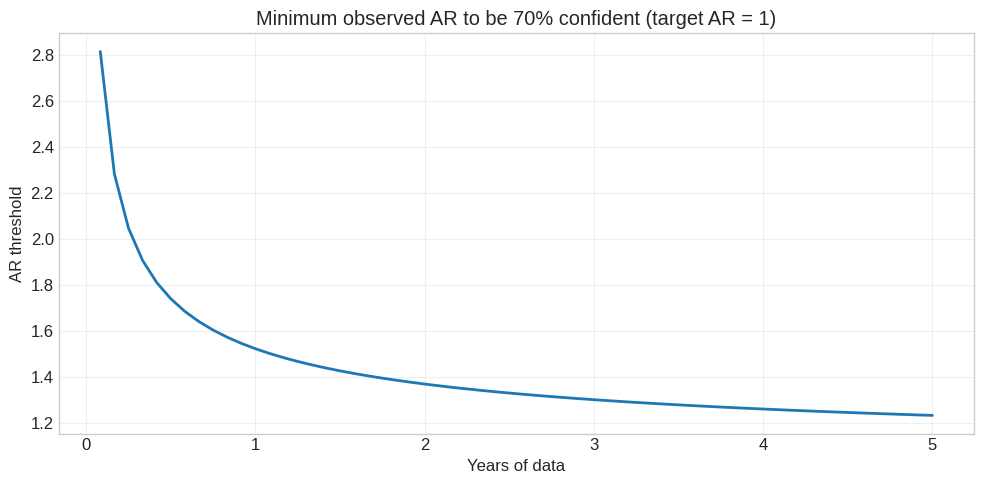

In [28]:
def plot_alpha_threshold(ar, T_max, p):
    """Plot the AR threshold needed to be p-confident that true AR > target."""
    T = np.arange(1, T_max + 1)
    z = norm.ppf(p)
    threshold = z / np.sqrt(T / 12) + ar

    plt.figure(figsize=(10, 5))
    plt.plot(T / 12, threshold, linewidth=2)
    plt.xlabel('Years of data')
    plt.ylabel('AR threshold')
    plt.title(f'Minimum observed AR to be {p:.0%} confident (target AR = {ar})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# When to promote: need p=70% confidence that AR > 1
plot_alpha_threshold(ar=1, T_max=5*12, p=0.7)

- The threshold is very stringent early on, but converges to the target as uncertainty shrinks
- With a true AR of ~1.5 it takes about a year to clear the bar
- The big takeaway: **the longer the sample, the lower the realized AR needs to be** for you to be convinced

### When to fire a pod / abandon a strategy?

Flip the question: you give up when you are $p = 75\%$ confident the AR is *below* your target.

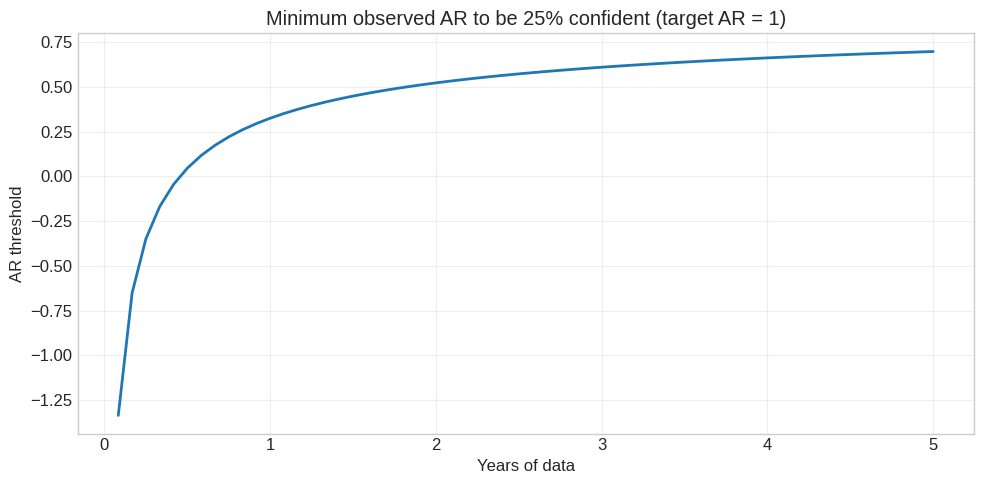

In [29]:
# When to fire: p=75% confidence that AR < target
plot_alpha_threshold(ar=1, T_max=5*12, p=0.25)

> **🤔 Think and Code:**
>
> 1. Call `plot_alpha_threshold(ar=1, T_max=5*12, p=0.75)`. How does the threshold differ from the "fire" plot?
> 2. What happens if you double the target AR? How much longer do you need to wait?

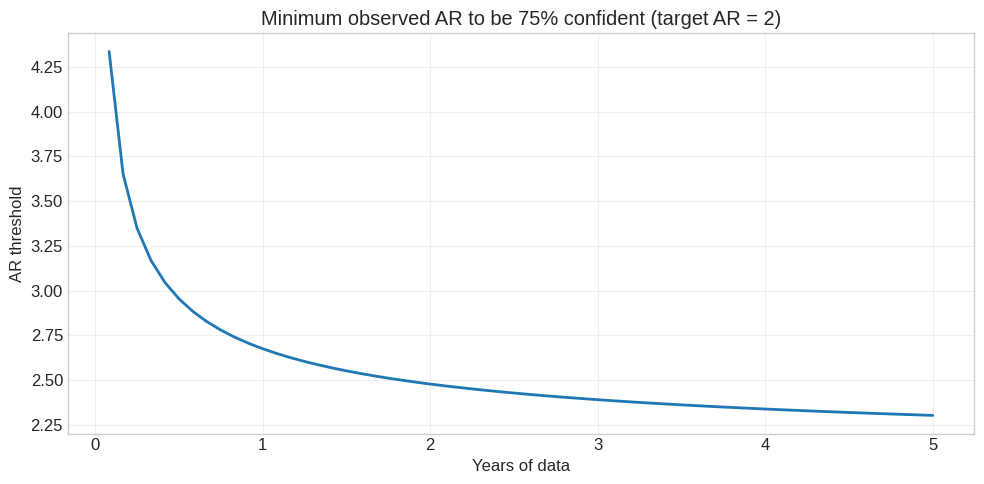

In [47]:
# Your code here
plot_alpha_threshold(ar=2, T_max=5*12, p=0.75)

> **📌 Remember:**
>
> Under i.i.d. returns: $\text{Appraisal Ratio} = \dfrac{t_\alpha}{\sqrt{T}}$
>
> This links the appraisal ratio directly to the statistical significance of alpha for a given sample length.

---

## MVE Example: Overfitting in Action <a id="mve-example"></a>

We'll build a mean-variance efficient (MVE) portfolio from Fama-French factors and see how in-sample performance can be spectacularly misleading.

In [30]:
def MVE(df, VolTarget=0.1/12**0.5):
    """Estimate MVE portfolio and report performance."""
    VarR = df.cov()
    ER = df.mean()
    W = ER @ np.linalg.inv(VarR)
    VarW = W @ VarR @ W
    w = VolTarget / VarW**0.5
    Ww = w * W
    SR = (df @ Ww).mean() / (df @ Ww).std() * 12**0.5
    vol = (df @ Ww).std() * 12**0.5

    x = sm.add_constant(df['Mkt-RF'])
    y = df @ Ww
    regresult = sm.OLS(y, x).fit()
    alpha = regresult.params[0] * 12
    t_alpha = regresult.tvalues[0]
    AR = alpha / (regresult.resid.std() * 12**0.5)

    return {'SR': SR, 'Vol': vol, 'Alpha': alpha, 'tAlpha': t_alpha, 'AR': AR}

# Estimate AND evaluate on the full sample — this is NOT a valid backtest!
MVE(df_ff6.drop(columns='RF'))

{'SR': np.float64(1.1781262121481013),
 'Vol': 0.10000000000000003,
 'Alpha': np.float64(0.09979050295270363),
 'tAlpha': np.float64(8.502681772029339),
 'AR': np.float64(1.0842776731632116)}

> **⚠️ Caution:**
>
> This strategy uses **full-sample** moments to construct weights, then evaluates
> on the **same sample**. The SR is guaranteed to look amazing. This is the most
> severe form of look-ahead bias — it is not a valid trading strategy.

A valid trading strategy can only use information known at the time of the trade. Let's split the sample properly: estimate on data up to 2013, test on 2014+.

In [31]:
def MVE(df_est, df_test, VolTarget=0.1/12**0.5):
    """Estimate MVE on df_est, evaluate on df_test."""
    VarR = df_est.cov()
    ER = df_est.mean()
    W = ER @ np.linalg.inv(VarR)
    VarW = W @ VarR @ W
    w = VolTarget / VarW**0.5
    Ww = w * W
    SR = (df_test @ Ww).mean() / (df_test @ Ww).std() * 12**0.5
    vol = (df_test @ Ww).std() * 12**0.5

    x = sm.add_constant(df_test['Mkt-RF'])
    y = df_test @ Ww
    regresult = sm.OLS(y, x).fit()
    alpha = regresult.params[0] * 12
    t_alpha = regresult.tvalues[0]
    AR = alpha / (regresult.resid.std() * 12**0.5)

    return {'SR': SR, 'Vol': vol, 'Alpha': alpha, 'tAlpha': t_alpha, 'AR': AR}

# In-sample (same data for estimation and evaluation)
print("In-sample:  ", MVE(df_ff6[:'2013'].drop(columns='RF'), df_ff6[:'2013'].drop(columns='RF')))
# Out-of-sample (estimate on pre-2013, test on 2014+)
print("Out-of-sample:", MVE(df_ff6[:'2013'].drop(columns='RF'), df_ff6['2014':].drop(columns='RF')))

In-sample:   {'SR': np.float64(1.3429793756828021), 'Vol': 0.09999999999999998, 'Alpha': np.float64(0.12313876343103544), 'tAlpha': np.float64(9.074422565904829), 'AR': np.float64(1.2859736375018127)}
Out-of-sample: {'SR': np.float64(0.5406952873332458), 'Vol': 0.12132056817102535, 'Alpha': np.float64(0.031832531758214065), 'tAlpha': np.float64(0.9525914641431102), 'AR': np.float64(0.2809334369018167)}


> **🤔 Think and Code:**
>
> 1. What happened to the SR out of sample? Is that expected?
> 2. Can you even reject a zero alpha with ~10 years of test data?
> 3. If the true AR is 1.3, how many years would you need to reject zero alpha?

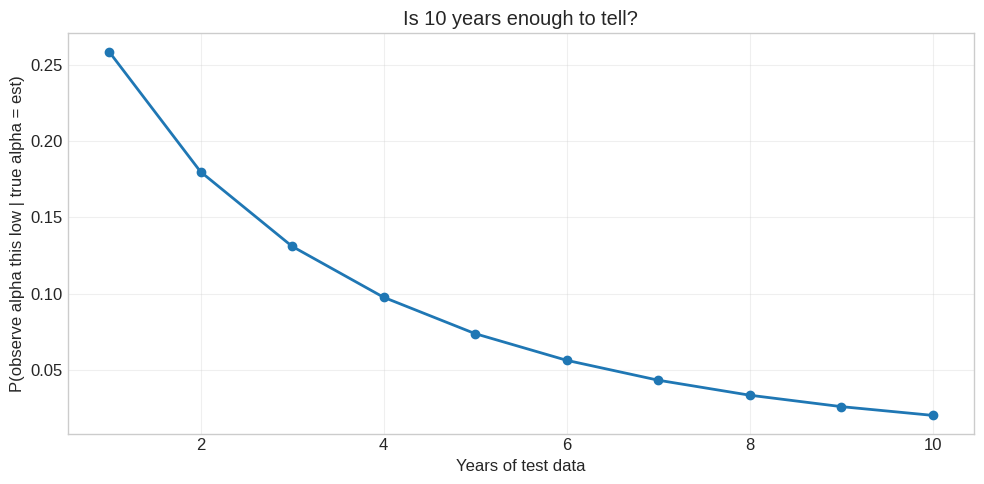

In [32]:
# Under the null that the estimation-sample AR is true,
# what is the probability of observing our test-sample alpha?
alpha_est = 0.12
alpha_test = 0.038
ar_est = 1.3
ar_test = 0.3
sigmae_test = alpha_test / ar_test  # recover residual vol from the test AR

T = np.arange(1, 11)
probabilities = norm.cdf((alpha_test - alpha_est) / sigmae_test * np.sqrt(T))

plt.figure(figsize=(10, 5))
plt.plot(T, probabilities, 'o-', linewidth=2)
plt.xlabel('Years of test data')
plt.ylabel('P(observe alpha this low | true alpha = est)')
plt.title('Is 10 years enough to tell?')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- With only 1 year and a mediocre test alpha, there's still a 20%+ chance the true alpha is as high as in-sample
- **Design your test sample** with the test you want to run in mind — a sample that's too short cannot reject anything
- The longer you leave for testing, the more powerful your evaluation becomes

## The Basic Problem of Overfitting

Every sample estimate is a random variable. Optimization amplifies noise:
- It selects signals that are pure noise with no real predictive power
- It overweights real signals relative to their true importance
- It discards real signals that didn't show up strongly enough

![outofsample](https://github.com/amoreira2/UG54/blob/main/assets/plots/outofsample1.jpg?raw=1)

## Be Clear About Your Goal

The central goal is to calibrate your **discovery process**:
- Invest in strategies that truly have alpha; discard the ones that don't
- Be tough enough to avoid noise, but not so tough you throw away real ideas
- The better you know the quality of your discovery, the easier it is to size positions

> **💡 Key Insight:**
>
> The goal is not to find the strategy with the highest in-sample performance.
> It is to build a process that **reliably identifies genuine alpha** while
> discarding noise. Overfitting is the default — discipline is the edge.

---

## Building a Diagnostics Toolkit <a id="diagnostics-toolkit"></a>

You should look at **many** things when evaluating a strategy:

1. Sharpe Ratio + t-stat of the SR
2. Alpha, t-stat of alpha, appraisal ratio
3. Cumulative return and **drawdown** plots
4. Tail behavior (% of observations beyond ±3σ)
5. **Fraction to half**: how many observations must you remove to halve the SR?
6. Compare everything against the market benchmark

We'll separate **strategy estimation** (computing weights) from **diagnostics** (evaluating performance). This makes the diagnostics function portable across any strategy.

In [33]:
def MVE(df, VolTarget):
    """Return MVE weights given factor data and a volatility target."""
    VarR = df.cov()
    ER = df.mean()
    W = ER @ np.linalg.inv(VarR)
    VarW = W @ VarR @ W
    w = VolTarget / VarW**0.5
    Ww = w * W
    return Ww

Ww = MVE(df_ff6['1963':'1993'].drop(columns='RF'), VolTarget=0.1/12**0.5)
print("MVE weights:", dict(zip(df_ff6.drop(columns='RF').columns, Ww.round(3))))

MVE weights: {'Mkt-RF': np.float64(0.288), 'SMB': np.float64(0.399), 'HML': np.float64(0.618), 'RMW': np.float64(1.534), 'CMA': np.float64(1.038), 'MOM': np.float64(0.442)}


### Sharpe Ratio Standard Error

The SR is not a simple average, so standard errors need special treatment. Two approaches:

**1. Analytical (assuming normality):**

$$\sigma(SR) = \sqrt{\frac{1}{T-1}\left(1 + \frac{SR^2}{2}\right)}$$

**2. Bootstrap:** Resample returns with replacement $M$ times, compute the SR each time, and take the standard deviation across bootstrap samples.

In [34]:
def SR_vol(R):
    """Sharpe ratio standard error (normal assumption)."""
    SR = R.mean() / R.std()
    T = R.shape[0]
    return (1 / (T - 1) * (1 + SR**2 / 2))**0.5

def SR_vol_boot(R, N=10000):
    """Sharpe ratio standard error via bootstrap. Returns (std, 5th percentile)."""
    T = R.shape[0]
    SR_boot = np.array([R.sample(n=T, replace=True).pipe(lambda x: x.mean()/x.std()) for _ in range(N)])
    return SR_boot.std(), np.percentile(SR_boot, 5)

# Example: market SR standard error
df_est = df_ff6['1963':'2012']
print(f"Analytical SE: {SR_vol(df_est['Mkt-RF']):.4f}")
print(f"Bootstrap SE:  {SR_vol_boot(df_est['Mkt-RF'])[0]:.4f}")

Analytical SE: 0.0412
Bootstrap SE:  0.0425


### Fraction to Half

How many observations must you remove to halve the Sharpe ratio? The algorithm is **greedy**: at each step, remove the single observation whose deletion decreases the SR the most. Repeat until SR drops below half its original value.

> **💡 Key Insight:**
>
> If removing just 2–3% of observations halves your Sharpe ratio, those few
> dates are doing all the heavy lifting. That is **fragile** performance.

In [35]:
def fractiontohalf(R):
    """Fraction of highest returns you must remove to halve the Sharpe ratio."""
    SR_original = R.mean() / R.std()
    target = SR_original / 2
    T = len(R)
    R_rem = R.copy()
    # Remove from the highest return downward
    order = R_rem.sort_values(ascending=False).index
    removed = 0

    for idx in order:
        if R_rem.mean() / R_rem.std() <= target or len(R_rem) <= 2:
            break
        R_rem = R_rem.drop(idx)
        removed += 1

    return removed / T

# Test on the market factor
frac = fractiontohalf(df_est['Mkt-RF'])
print(f"Fraction to half (Mkt-RF, 1963-2012): {frac:.1%}")

Fraction to half (Mkt-RF, 1963-2012): 2.2%


> **📌 Remember: Drawdown Plots**
>
> A drawdown measures how far a strategy has fallen from its peak.
> This tells you how long the painful losing periods last — critical for
> fund lockup decisions, manager evaluation, and your own pain tolerance.

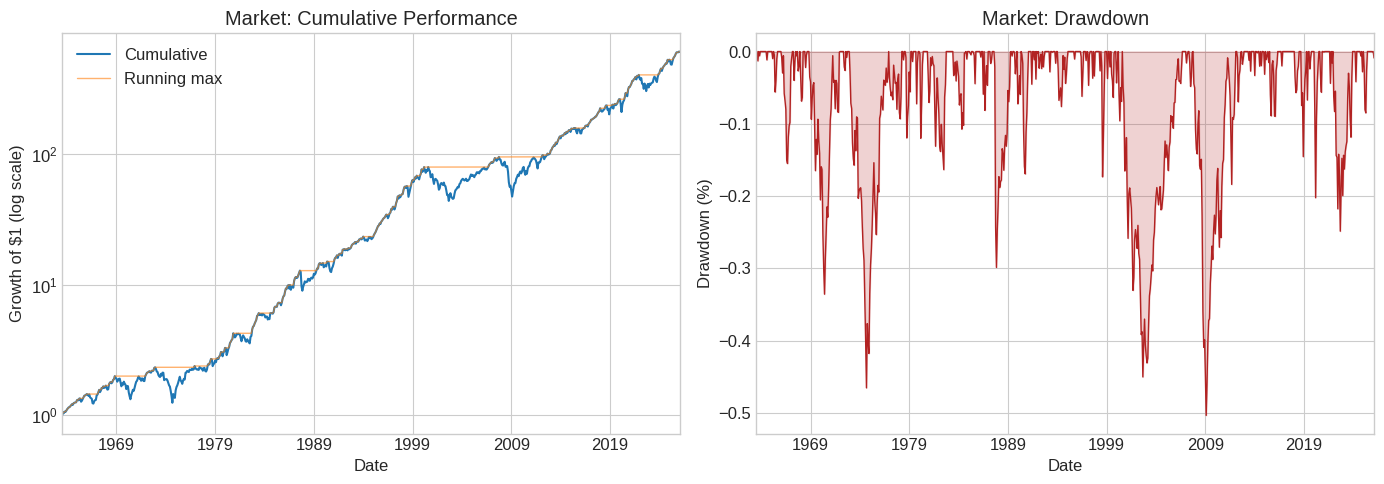

In [36]:
# Standalone drawdown example: the market
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cumperf = (df_ff6['Mkt-RF'] + df_ff6.RF + 1).cumprod()
running_max = cumperf.cummax()
drawdown = (cumperf - running_max) / running_max

cumperf.plot(ax=ax[0], logy=True, linewidth=1.5, label='Cumulative')
running_max.plot(ax=ax[0], logy=True, linewidth=1, alpha=0.6, label='Running max')
ax[0].set_title('Market: Cumulative Performance')
ax[0].legend()
ax[0].set_ylabel('Growth of $1 (log scale)')

drawdown.plot(ax=ax[1], linewidth=1, color='firebrick')
ax[1].set_title('Market: Drawdown')
ax[1].set_ylabel('Drawdown (%)')
ax[1].fill_between(drawdown.index, drawdown, alpha=0.2, color='firebrick')
plt.tight_layout()
plt.show()

### The Complete Diagnostics Function

This function computes all the metrics above and produces a two-panel plot (cumulative returns + drawdown). Pass either portfolio weights `W` or a pre-computed return series `R`.

In [37]:
def Diagnostics(W, df, R=None):
    """Run a full diagnostic suite on a strategy."""
    results = {}

    Rf = df['RF']
    Factor = df['Mkt-RF']
    df = df.drop(columns=['RF'])
    if R is None:
        R = df @ W

    T = R.shape[0]

    # --- Performance metrics ---
    results['SR'] = R.mean() / R.std() * 12**0.5
    results['SR_factor'] = Factor.mean() / Factor.std() * 12**0.5
    results['Vol'] = R.std() * 12**0.5
    results['Vol_factor'] = Factor.std() * 12**0.5
    results['mean'] = R.mean() * 12
    results['t_mean'] = R.mean() / R.std() * T**0.5
    results['mean_factor'] = Factor.mean() * 12
    results['t_mean_factor'] = Factor.mean() / Factor.std() * T**0.5

    # --- Alpha regression ---
    x = sm.add_constant(Factor)
    regresult = sm.OLS(R, x).fit()
    results['alpha'] = regresult.params[0] * 12
    results['t_alpha'] = regresult.tvalues[0]
    results['AR'] = results['alpha'] / (regresult.resid.std() * 12**0.5)

    # --- Tail behavior ---
    results['tails'] = (R < -3*R.std()).mean() + (R > 3*R.std()).mean()
    results['tails_factor'] = (Factor < -3*Factor.std()).mean() + (Factor > 3*Factor.std()).mean()
    results['min_ret'] = R.min()
    results['min_factor'] = Factor.min()

    # --- Sharpe ratio t-test ---
    results['t_SR'] = results['SR'] / (SR_vol(R) * 12**0.5)
    results['t_SR_factor'] = results['SR_factor'] / (SR_vol(Factor) * 12**0.5)

    # --- Fraction to half ---
    results['fraction_tohalf'] = fractiontohalf(R)
    results['fraction_tohalf_factor'] = fractiontohalf(Factor)

    # --- Plots: cumulative returns + drawdown ---
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    cum_port = (R + Rf + 1).cumprod()
    cum_mkt = (Factor + Rf + 1).cumprod()
    cum_port.plot(ax=ax[0], logy=True, linewidth=1.5, label='Portfolio')
    cum_mkt.plot(ax=ax[0], logy=True, linewidth=1, alpha=0.7, label='Market')
    ax[0].set_title('Cumulative Performance')
    ax[0].legend()
    ax[0].set_ylabel('Growth of $1 (log scale)')

    running_max = cum_port.cummax()
    dd = (cum_port - running_max) / running_max
    dd.plot(ax=ax[1], linewidth=1, color='firebrick')
    ax[1].fill_between(dd.index, dd, alpha=0.2, color='firebrick')
    ax[1].set_title('Portfolio Drawdown')
    ax[1].set_ylabel('Drawdown')
    plt.tight_layout()
    plt.show()

    formatted_dict = {key: [value] for key, value in results.items()}
    return pd.DataFrame(formatted_dict).T

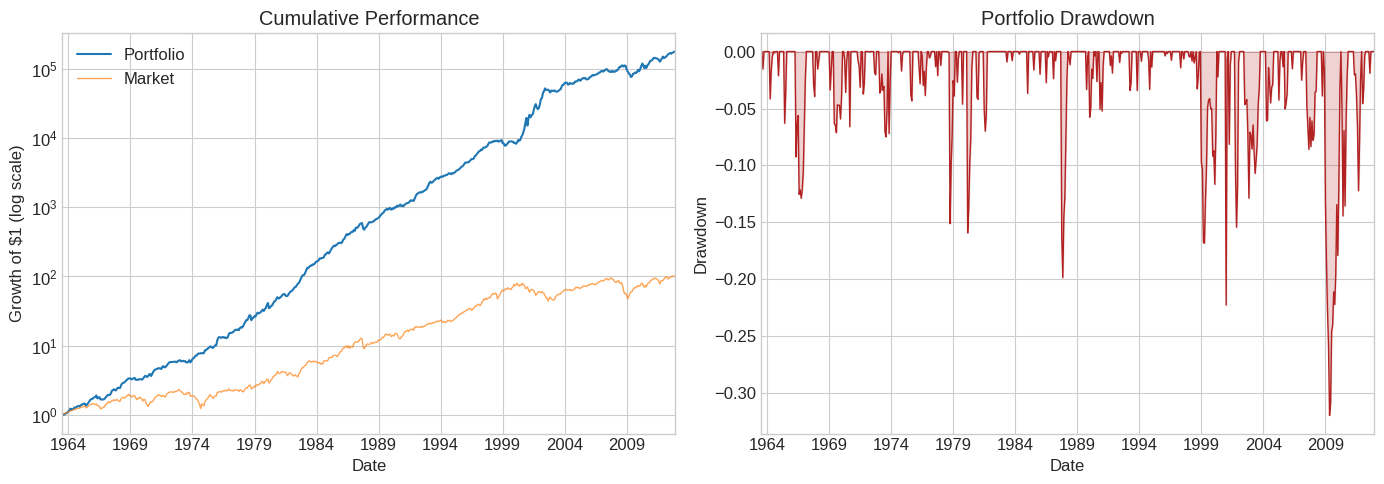

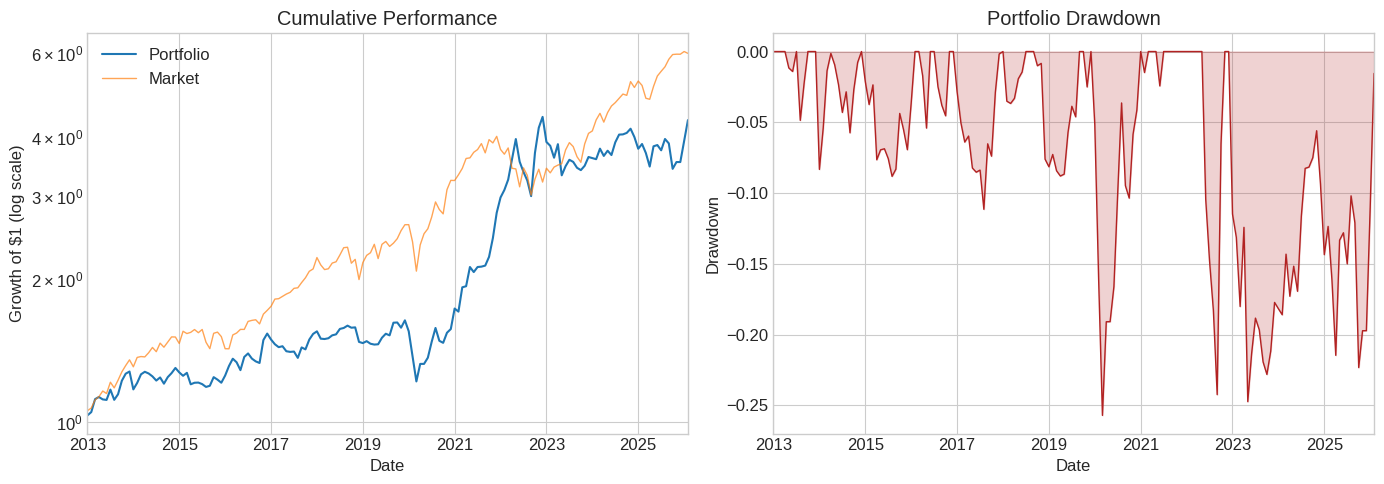

,Estimation,Test
SR,1.330330,0.608161
SR_factor,0.353067,0.895604
Vol,0.156115,0.184297
Vol_factor,0.156115,0.146479
mean,0.207685,0.112082
t_mean,9.359703,2.206768
mean_factor,0.055119,0.131187
t_mean_factor,2.484048,3.249781
alpha,0.193056,0.052713
t_alpha,8.969894,1.073237


In [38]:
split_year = 2012
df_est = df_ff6['1963':str(split_year)]
Volmkt = df_est['Mkt-RF'].std()
Ww = MVE(df_est.drop(columns='RF'), VolTarget=Volmkt)
df_test = df_ff6[str(split_year + 1):]

Results = pd.DataFrame()
Results['Estimation'] = Diagnostics(Ww, df_est)
Results['Test'] = Diagnostics(Ww, df_test)
Results

> **🤔 Think and Code:**
>
> Compare the estimation and test columns side by side.
> 1. Which metrics degrade the most out of sample?
> 2. What does `fraction_tohalf` tell you about robustness in each period?
> 3. How do the drawdown plots differ?

---

## Adjusting for Multiple Testing <a id="multiple-testing"></a>

When you try many signals, conventional t-test thresholds are too lenient. The **Bonferroni correction** is a simple (conservative) fix: divide your significance level by the number of tests.

![Bonferroni Correction](https://github.com/amoreira2/UG54/blob/main/assets/plots/bonferroni.jpg?raw=1)

The threshold jumps from 1.96 to ~3.0 as you go from 1 to 20 signals. Most of the correction happens in the first few signals.

**Example:** You try 100 ideas over 24 months. How many look significant even if *none* are real?

In [39]:
# 100 pure-noise strategies tested over 24 months
R = pd.DataFrame(norm.rvs(loc=0, scale=0.16/12**0.5, size=(24, 100)))
t = R.mean() / (R.std() / 24**0.5)
print(f"Strategies with t > 1.64: {(t > 1.64).sum()} out of 100")

Strategies with t > 1.64: 6 out of 100


> **🤔 Think and Code:**
>
> Now suppose one of the 100 signals is real (annualized SR = 1).
> 1. What is your hit rate — how often do you find the correct idea?
> 2. What happens as you change the t-cutoff, the true SR, or the sample length?

In [40]:
SR = 1
t_cutoff = 2
Nmonths = 48
Ideas = 100
simulations = 1000
number_of_correct = 0
number_of_wrong = 0

for i in range(simulations):
    R = pd.DataFrame(norm.rvs(loc=0, scale=1, size=(Nmonths, Ideas)))
    R.iloc[:, 0] = R.iloc[:, 0] + SR / 12**0.5  # first strategy is the real one
    t = R.mean() / (R.std() / Nmonths**0.5)

    number_of_correct += (t.iloc[0] > t_cutoff).sum()
    number_of_wrong += (t.iloc[1:] > t_cutoff).sum()

hit_rate = number_of_correct / (number_of_correct + number_of_wrong)
detection_rate = number_of_correct / simulations
print(f"Hit rate (correct / total flagged): {hit_rate:.1%}")
print(f"Detection rate (found the real one): {detection_rate:.1%}")

Hit rate (correct / total flagged): 16.7%
Detection rate (found the real one): 50.8%


The simulation reveals the core trade-off: a lenient cutoff finds the real signal but also many false positives. A strict cutoff avoids false discoveries but may miss the true signal entirely. There is no free lunch — you must choose your error tolerance.

---

## Sample Splitting Strategies <a id="sample-splitting"></a>

A few popular approaches:

1. **Rolling window** — re-estimate at each date using the most recent $W$ months
2. **Odd/even split** — use odd months for estimation, even for testing (and vice versa)
3. **Two-way split** — estimation sample + test sample
4. **Three-way split** — estimation + test (for model selection) + hold-out (for final evaluation)

### Application 1: Optimal Combination of Momentum and Value

We split the sample into two interleaved halves:
1. Odd months in even years + even months in odd years
2. The mirror image

This lets us **cross-validate**: estimate weights on one half, test on the other, then swap. We're not testing particular weights but an *approach* to portfolio construction.

We construct both samples using a function that flags odd-month/even-year combinations:

In [41]:
def sample(df):
    """Split data into two interleaved halves for cross-validation."""
    def is_odd(num):
        return num % 2 != 0
    evenyear_oddmonth = (~is_odd(df.index.year)) & (is_odd(df.index.month))
    oddyear_evenmonth = (is_odd(df.index.year)) & (~is_odd(df.index.month))
    sample1 = evenyear_oddmonth | oddyear_evenmonth
    sample2 = ~sample1
    return sample1, sample2

df_ff6 = get_factors('ff6', freq='monthly')
sample1, sample2 = sample(df_ff6)

Now run diagnostics in both directions:

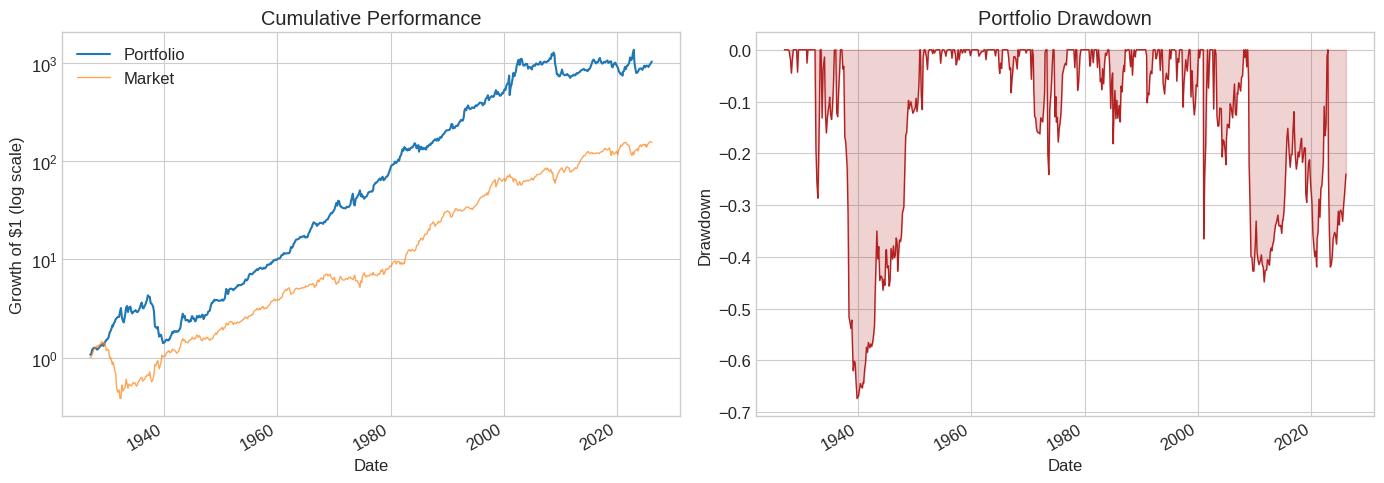

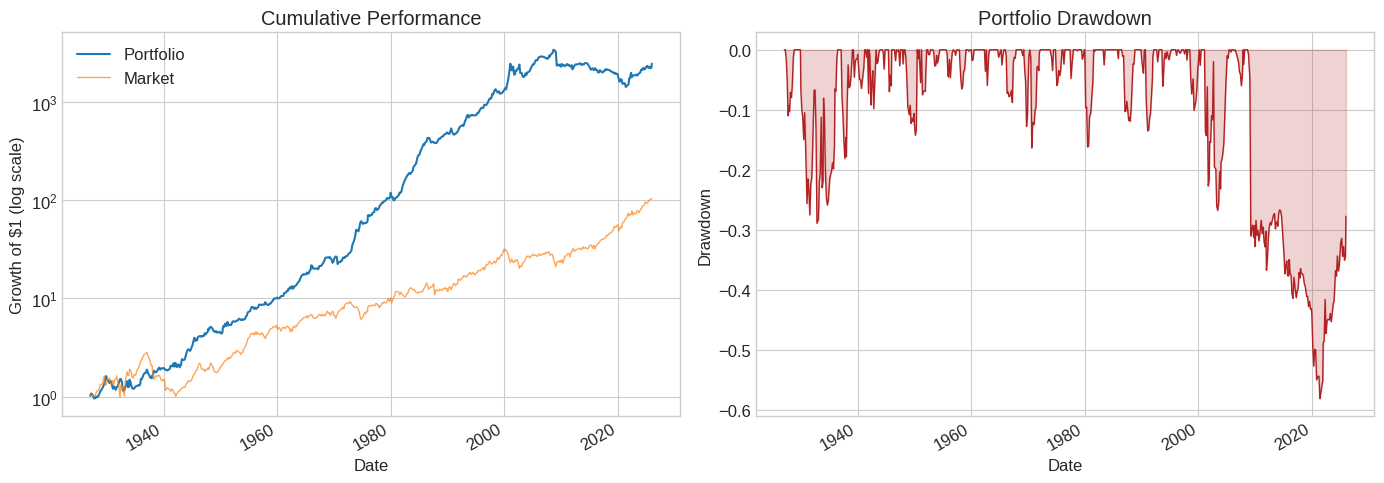

,Test_s2_est1,Test_s1_est2
SR,0.641697,0.823965
SR_factor,0.476925,0.420044
Vol,0.201888,0.170592
Vol_factor,0.180167,0.188076
mean,0.129551,0.140561
t_mean,4.518541,5.801987
mean_factor,0.085926,0.079000
t_mean_factor,3.358289,2.957758
alpha,0.149164,0.145893
t_alpha,5.259819,5.989741


In [42]:
# Direction 1: estimate on sample1, test on sample2
df_est = df_ff6.loc[sample1, ['HML', 'MOM', 'Mkt-RF', 'RF']]
df_test = df_ff6.loc[sample2, ['HML', 'MOM', 'Mkt-RF', 'RF']]
Ww = MVE(df_est[['HML', 'MOM']], VolTarget=df_est['Mkt-RF'].std())
Ww = np.append(Ww, 0)  # set market weight to zero

Results = pd.DataFrame()
Results['Test_s2_est1'] = Diagnostics(Ww, df_test)

# Direction 2: estimate on sample2, test on sample1
df_est = df_ff6.loc[sample2, ['HML', 'MOM', 'Mkt-RF', 'RF']]
df_test = df_ff6.loc[sample1, ['HML', 'MOM', 'Mkt-RF', 'RF']]
Ww = MVE(df_est[['HML', 'MOM']], VolTarget=df_est['Mkt-RF'].std())
Ww = np.append(Ww, 0)

Results['Test_s1_est2'] = Diagnostics(Ww, df_test)
Results

> **🤔 Think and Code:**
>
> - What do the cross-validated results tell you?
> - Both HML and MOM were published by famous professors around 1990. Does that matter?
> - Does knowing about publication bias change your interpretation?

> **📌 Remember: Robustifying Your Backtests**
>
> - Have a **hold-out sample** never used for estimation or model selection
> - Be careful that information from the test sample doesn't leak into estimation
> - Keep track of your discarded ideas — they matter for multiple-testing corrections
> - When tuning is needed, you must have three splits: estimation, test, and hold-out

### Application 2: Fine-Tuning the Look-Back Window

We'll compare rolling-window strategies with different look-back lengths to find which works best. The trade-off:
- **Too short** → picks up noise
- **Too long** → moments may no longer reflect the future

We split the data into two parts:
- **Estimation + Test**: everything before 2003 (for window tuning)
- **Hold-out**: 2003 onwards (for final evaluation — don't peek until you're done tuning!)

In [43]:
# Split into estimation/test vs. hold-out
holdout_sample = df_ff6.index.year > 2002
df_hold = df_ff6.loc[holdout_sample, ['HML', 'MOM', 'Mkt-RF', 'RF']]
df_EstTest = df_ff6.loc[~holdout_sample, ['HML', 'MOM', 'Mkt-RF', 'RF']]
print(f"Est+Test: {df_EstTest.index[0].strftime('%Y-%m')} to {df_EstTest.index[-1].strftime('%Y-%m')} ({len(df_EstTest)} months)")
print(f"Hold-out: {df_hold.index[0].strftime('%Y-%m')} to {df_hold.index[-1].strftime('%Y-%m')} ({len(df_hold)} months)")

Est+Test: 1927-01 to 2002-12 (912 months)
Hold-out: 2003-01 to 2026-02 (278 months)


Let's start by building a single rolling-window strategy with a 60-month look-back:

In [44]:
window = 60
df = df_EstTest.copy()
df['Strategy'] = np.nan

for d in df.index[window:]:
    df_temp = df.loc[d - pd.DateOffset(months=window):d - pd.DateOffset(months=1)].copy()
    X = MVE(df_temp[['HML', 'MOM']], VolTarget=df_temp['Mkt-RF'].std())
    df.at[d, 'Strategy'] = df.loc[d, ['HML', 'MOM']] @ X

df.dropna().tail()

,HML,MOM,Mkt-RF,RF,Strategy
Date,,,,,
2002-08-01,0.0301,0.0187,0.0050,0.0014,0.033837
2002-09-01,0.0126,0.0918,-0.1034,0.0014,0.071792
2002-10-01,-0.0376,-0.0558,0.0784,0.0014,-0.064856
2002-11-01,-0.0116,-0.1643,0.0596,0.0012,-0.124988
2002-12-01,0.0211,0.0972,-0.0576,0.0011,0.078467


Note: early observations are NaN because we need the full look-back window before producing a signal. Let's run diagnostics:

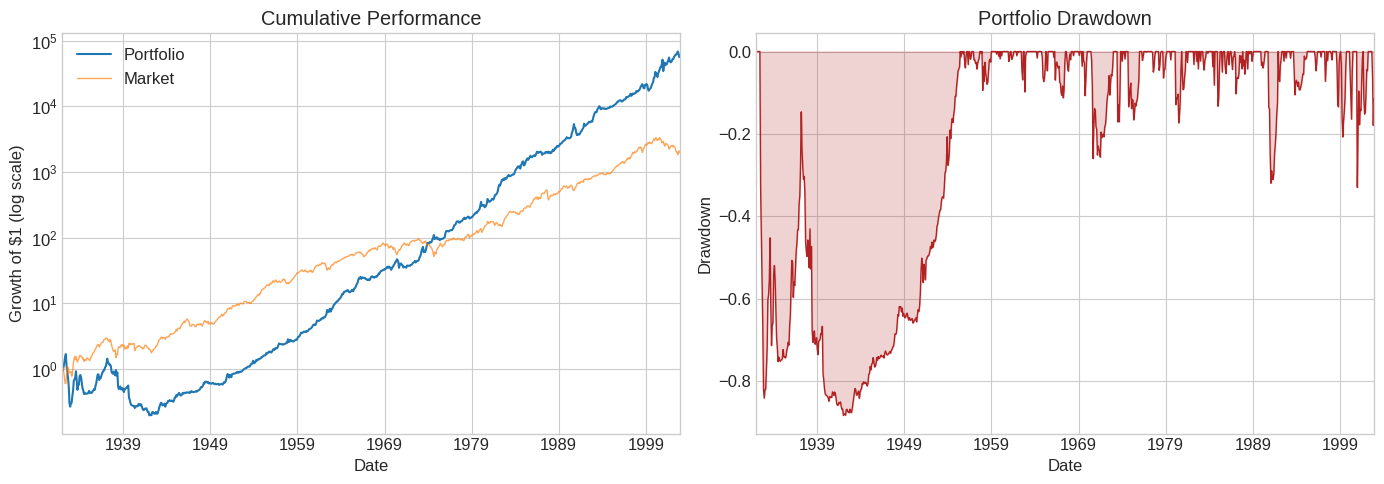

,0
SR,0.628215
SR_factor,0.465306
Vol,0.234898
Vol_factor,0.185690
mean,0.147566
t_mean,5.293436
mean_factor,0.086403
t_mean_factor,3.920737
alpha,0.153827
t_alpha,5.474622


In [45]:
# Pass the strategy return directly (weights are time-varying)
df = df.dropna()
Diagnostics(0, df, R=df['Strategy'])

Now let's generalize this into a function and compare multiple window lengths:

In [46]:
def RollingEval(df, window):
    """Rolling-window MVE strategy with given look-back."""
    df = df.copy()
    df['Strategy'] = np.nan
    for d in df.index[window:]:
        df_temp = df.loc[d - pd.DateOffset(months=window):d - pd.DateOffset(months=1)].copy()
        X = MVE(df_temp[['HML', 'MOM']], VolTarget=df_temp['Mkt-RF'].std())
        df.at[d, 'Strategy'] = df.loc[d, ['HML', 'MOM']] @ X
    return df

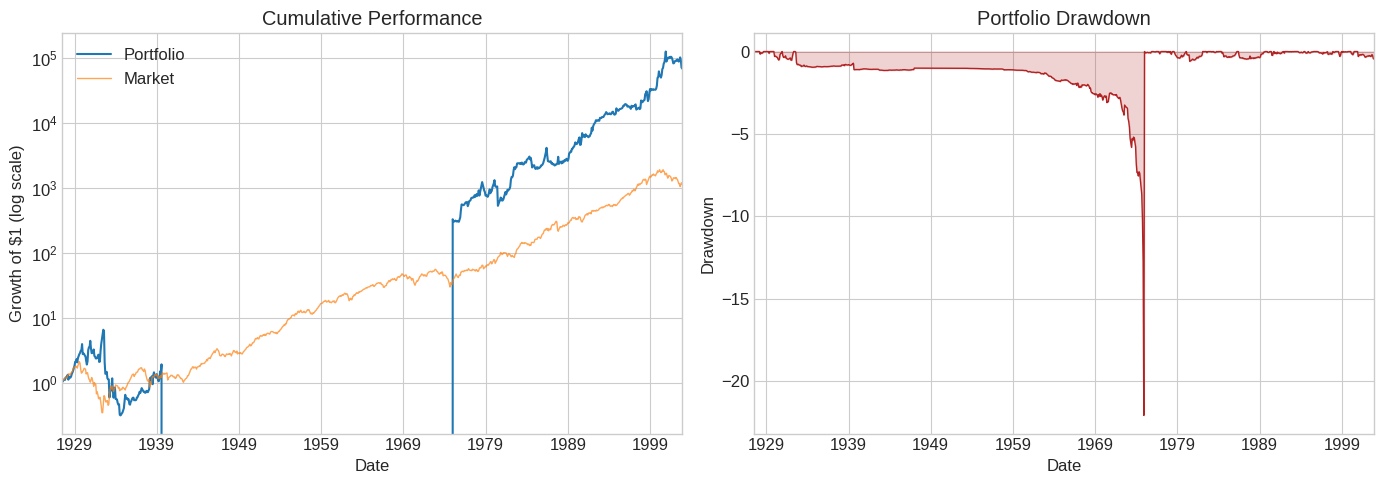

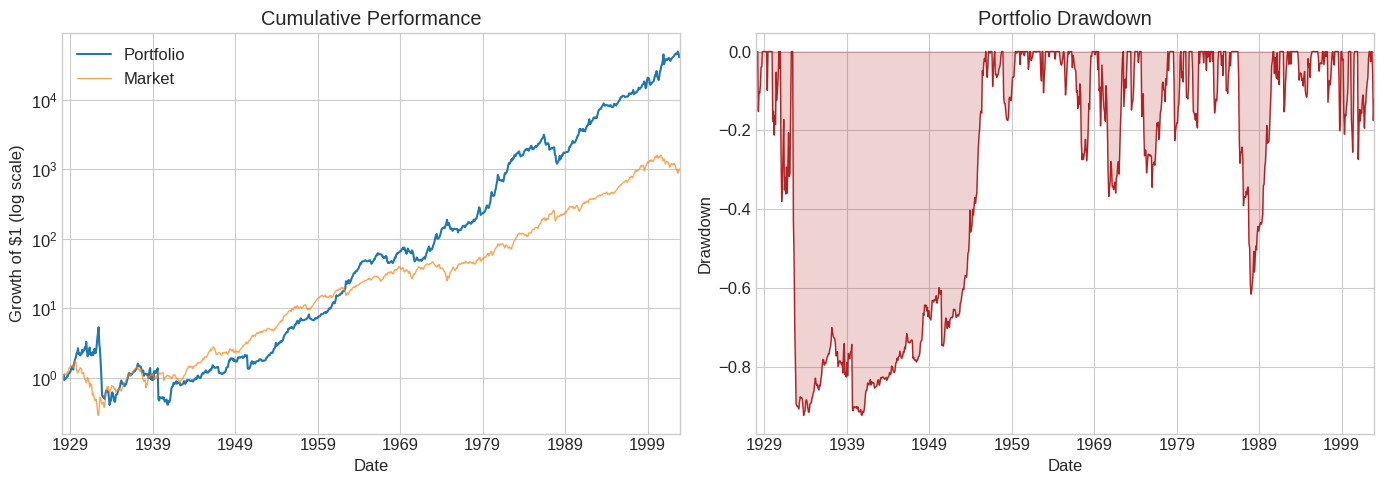

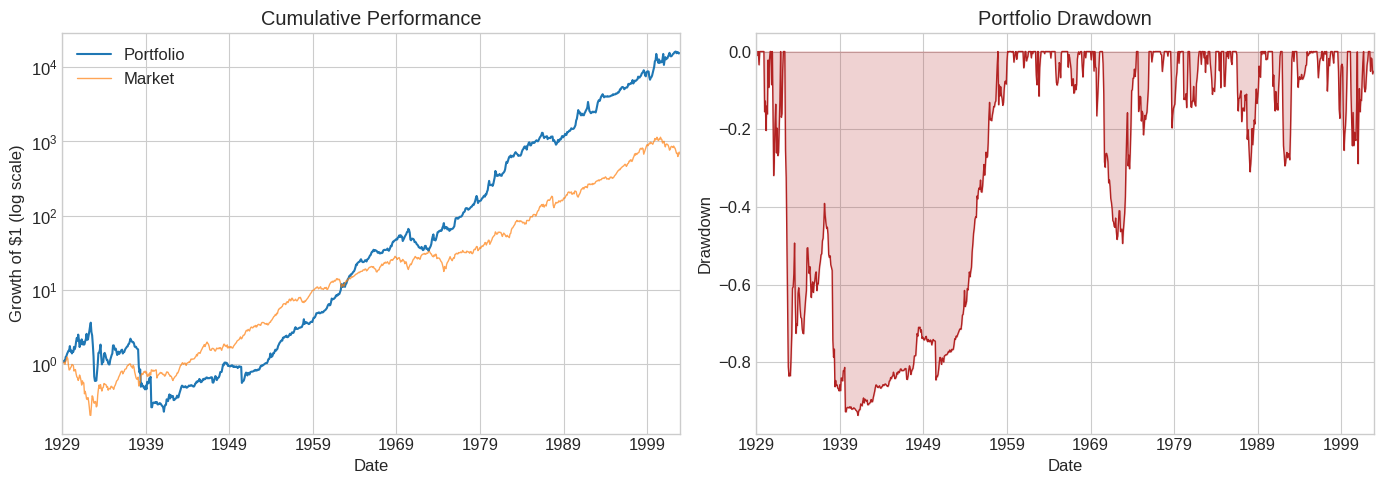

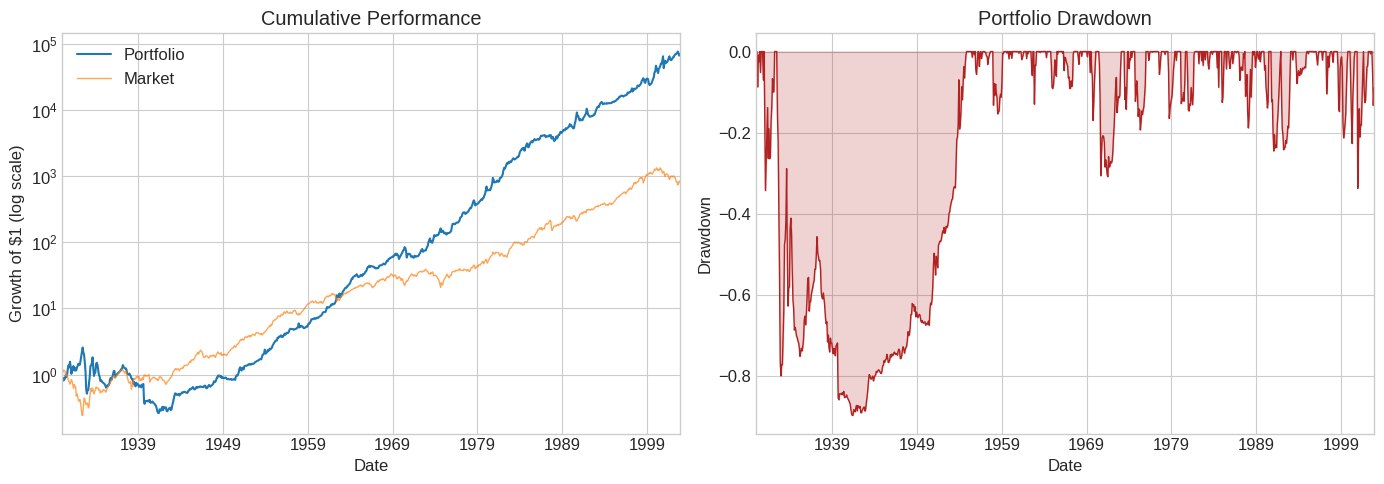

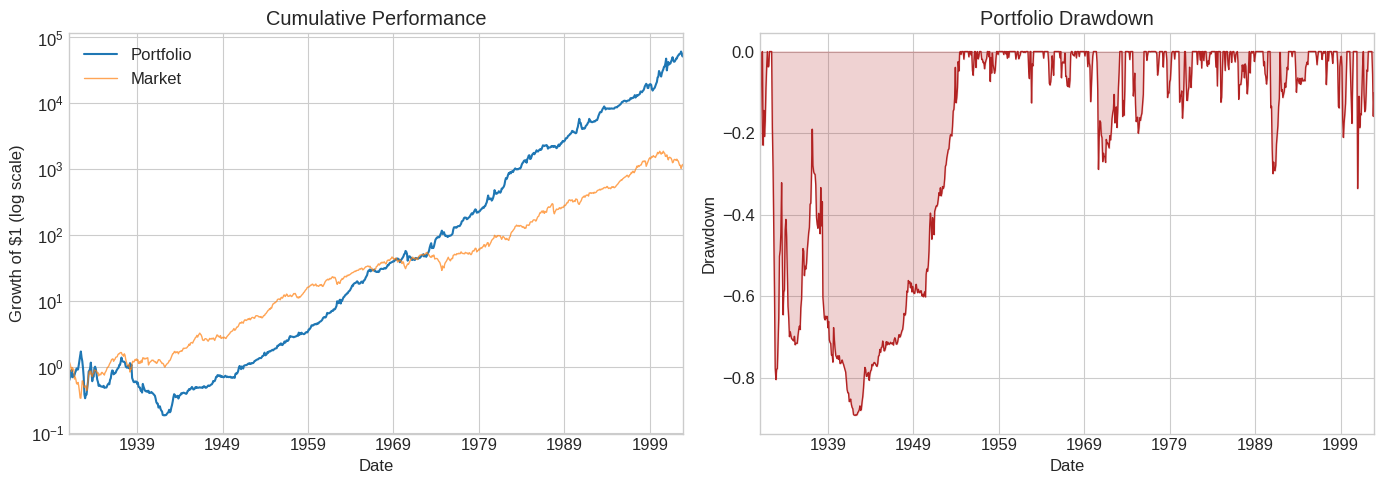

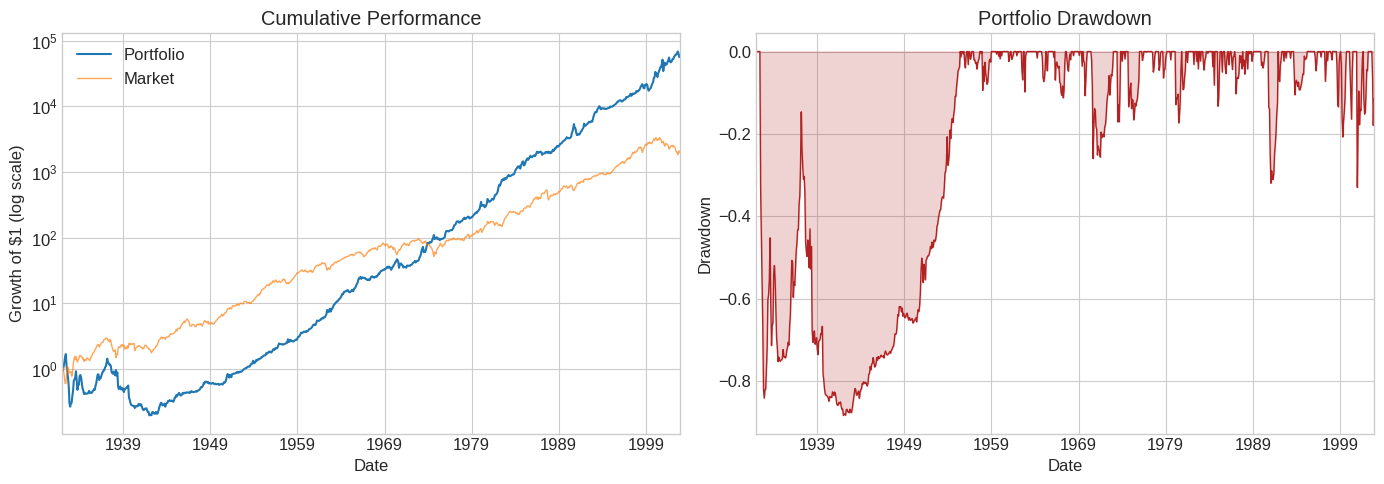

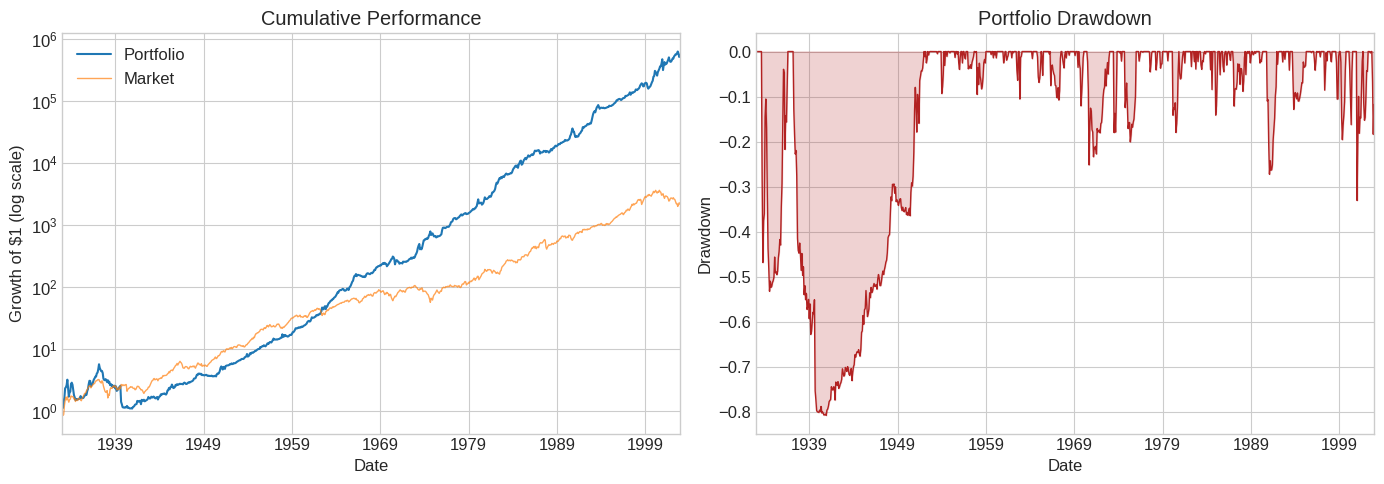

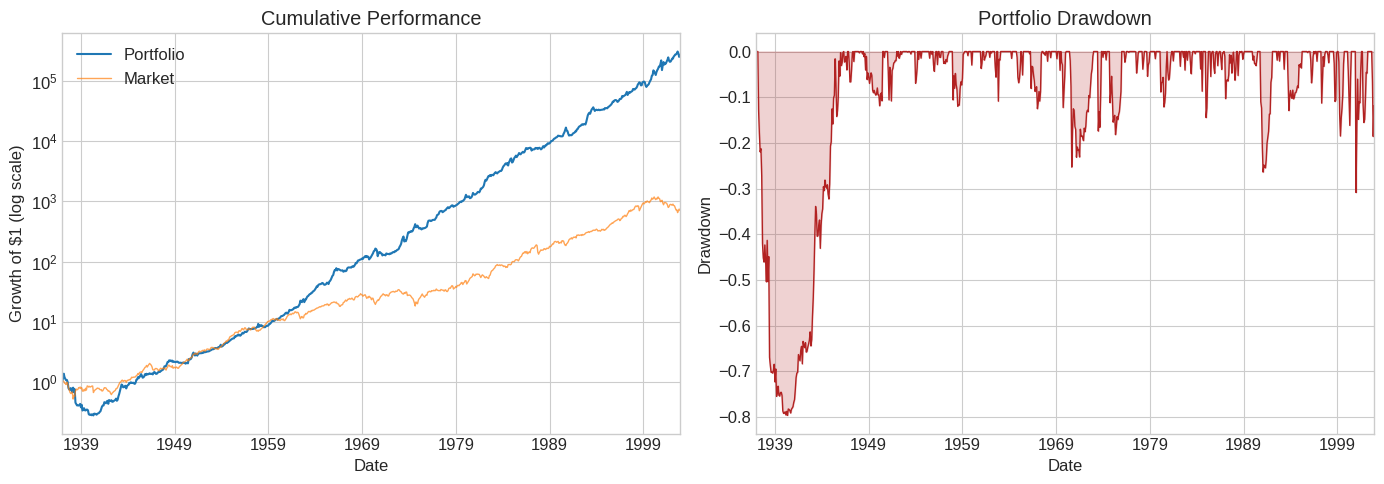

,6,12,24,36,48,60,72,120
SR,0.249440,0.540745,0.502713,0.610186,0.606302,0.628215,0.826353,0.896442
SR_factor,0.386169,0.375718,0.358569,0.378280,0.409796,0.465306,0.502563,0.449350
Vol,0.565274,0.272617,0.263416,0.241707,0.238639,0.234898,0.212463,0.188246
Vol_factor,0.194064,0.194284,0.194599,0.192863,0.191572,0.185690,0.172521,0.160687
mean,0.141002,0.147416,0.132423,0.147486,0.144687,0.147566,0.175569,0.168751
t_mean,2.167403,4.682989,4.324500,5.213428,5.144647,5.293436,6.913765,7.282726
mean_factor,0.074942,0.072996,0.069777,0.072956,0.078506,0.086403,0.086703,0.072205
t_mean_factor,3.355453,3.253810,3.084524,3.232028,3.477237,3.920737,4.204742,3.650536
alpha,0.171443,0.161829,0.137755,0.150278,0.147430,0.153827,0.172233,0.179234
t_alpha,2.643464,5.159333,4.479317,5.280142,5.204850,5.474622,6.711322,7.725470


In [22]:
# Compare multiple window lengths
windows = [6, 12, 24, 36, 48, 60, 72, 120]
Results_windows = pd.DataFrame()

for w in windows:
    Returns = RollingEval(df_EstTest.copy(), w).dropna()
    Results_windows[w] = Diagnostics(0, Returns, R=Returns['Strategy'])

Results_windows

> **⚠️ Caution:**
>
> Once you peek at the hold-out sample, you **must stop tuning**.
> Any further adjustment contaminates your out-of-sample evidence.
> Make your choice of window length now, before looking.

- Is the pattern across windows consistent with better estimation from longer histories?
- What else would you want to examine before committing?

### Ready to look at the hold-out sample?

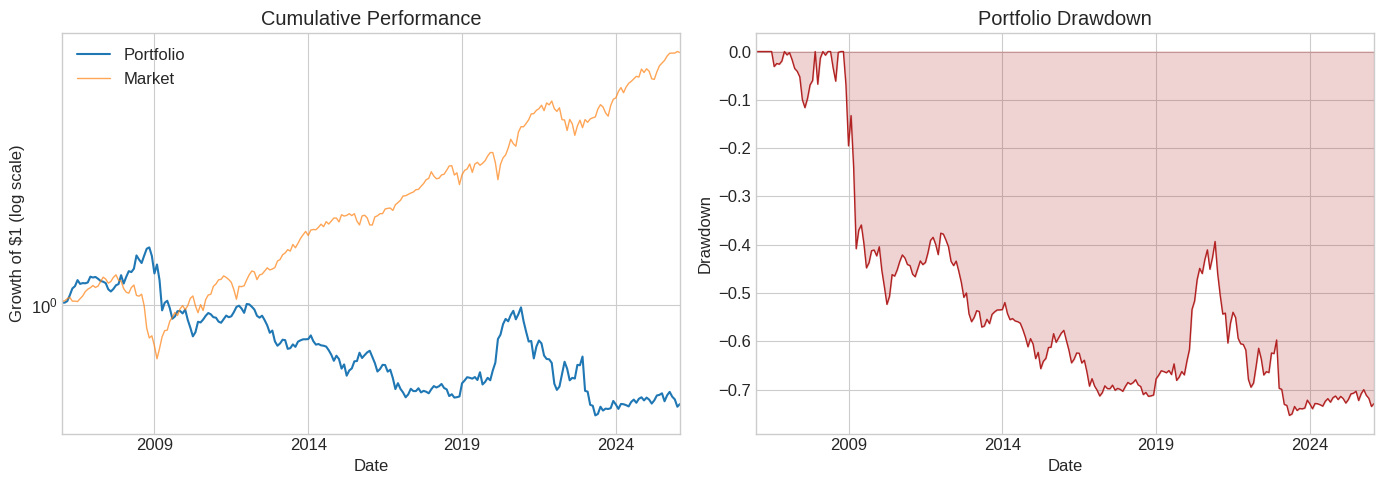

,0
SR,-0.206387
SR_factor,0.648509
Vol,0.188166
Vol_factor,0.155166
mean,-0.038835
t_mean,-0.926827
mean_factor,0.100626
t_mean_factor,2.912279
alpha,-0.018258
t_alpha,-0.433587


In [23]:
# Final evaluation on the hold-out sample
# Choose a window length based on the analysis above
chosen_window = 36
Returns_holdout = RollingEval(df_hold.copy(), chosen_window).dropna()
Diagnostics(0, Returns_holdout, R=Returns_holdout['Strategy'])

> **🤔 Think and Code:**
>
> What do you conclude? Did the tuned strategy survive the hold-out test?
> How does the hold-out SR compare to what you saw in the estimation/test period?

---

## Publication Bias <a id="publication-bias"></a>

We often investigate a strategy *because* it performed well historically. This selection mechanism biases our analysis toward strategies that look amazing.

One clean setting: **academic papers**. We know exactly when a paper was published and what sample it used. A nice study of this is [McLean & Pontiff (2016)](https://onlinelibrary.wiley.com/doi/pdf/10.1111/jofi.12365): *Does Academic Research Destroy Stock Return Predictability?*

**Application: HML (Fama-French 1993)**

The original paper used data from 1963–1993:

![outofsample](https://github.com/amoreira2/UG54/blob/main/assets/plots/outofsample2.jpg?raw=1)

The HML alpha was enormous: 0.56% per month with a negative market beta. Let's check what happened *before* and *after* the publication sample.

In [24]:
# Define pre-, during, and post-publication samples
sample_pre = df_ff6.index.year < 1964
sample_pub = (df_ff6.index.year >= 1964) & (df_ff6.index.year <= 1993)
sample_post = df_ff6.index.year > 1993

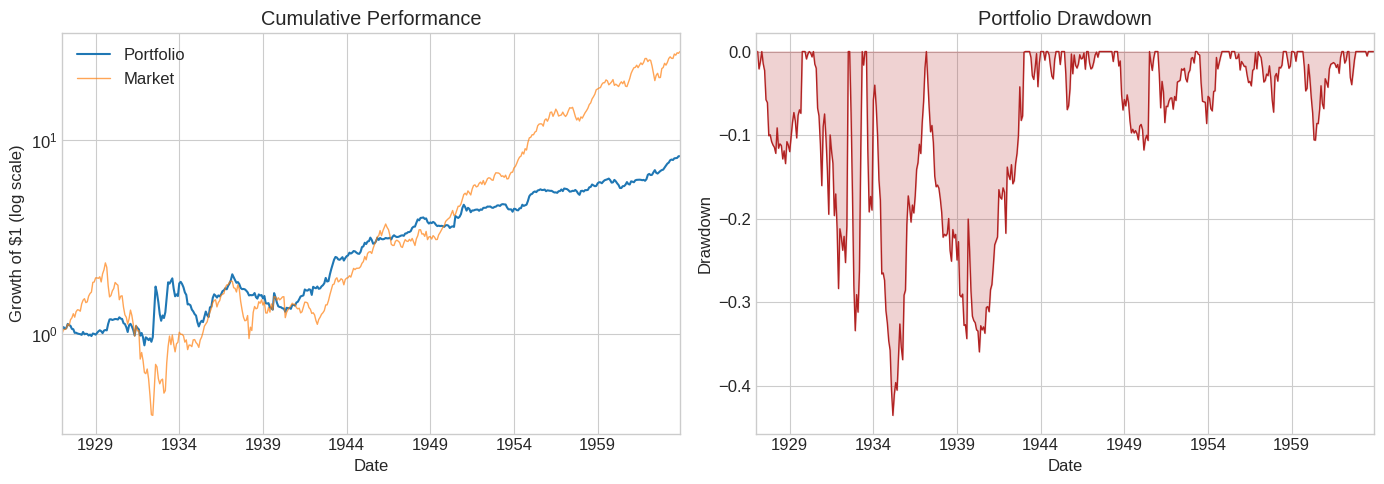

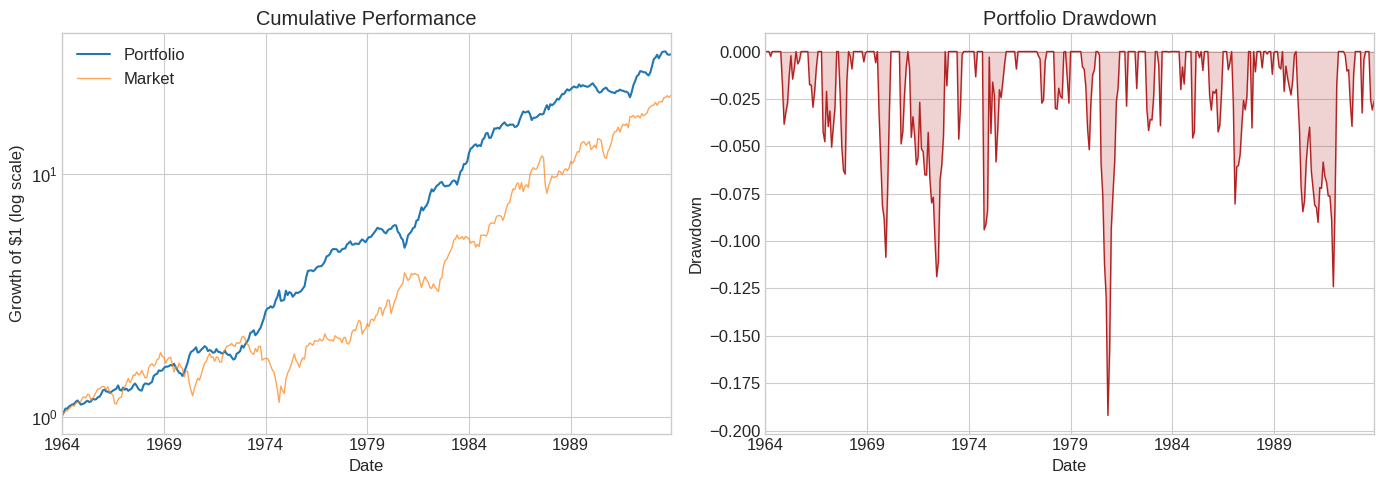

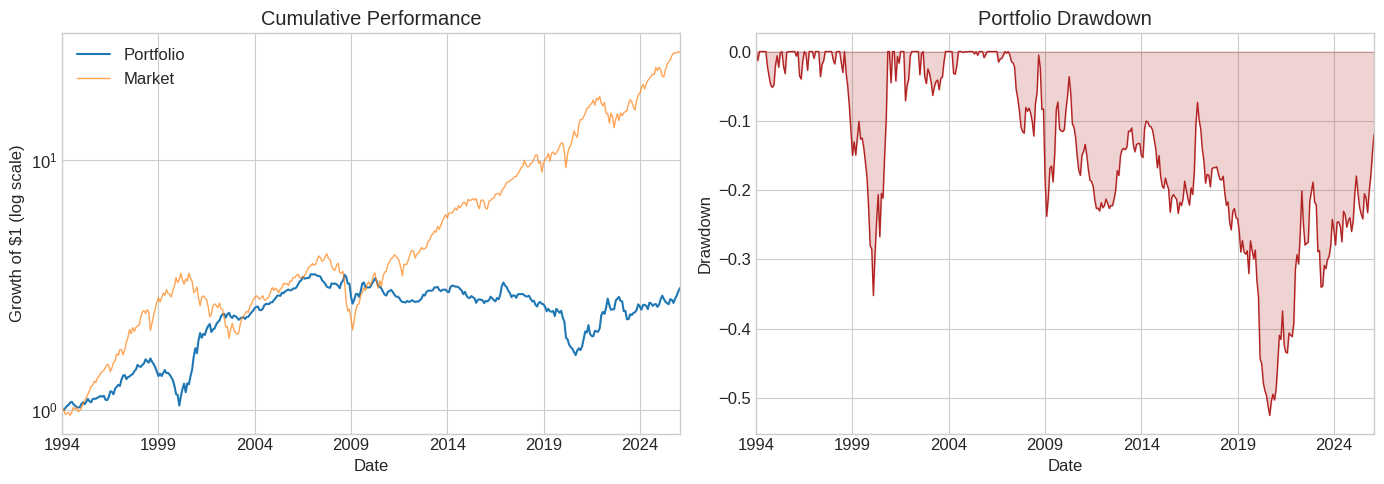

,Pre-publication,Publication,Post-publication
SR,0.358284,0.606106,0.151492
SR_factor,0.455018,0.316797,0.587939
Vol,0.151201,0.089731,0.114406
Vol_factor,0.225010,0.155683,0.153860
mean,0.054173,0.054387,0.017332
t_mean,2.179359,3.319780,0.859198
mean_factor,0.102384,0.049320,0.090460
t_mean_factor,2.767769,1.735167,3.334534
alpha,0.014970,0.064495,0.023929
t_alpha,0.725784,4.188700,1.173643


In [25]:
Results_pub = pd.DataFrame()

df = df_ff6[sample_pre]
Results_pub['Pre-publication'] = Diagnostics(0, df, R=df['HML'])

df = df_ff6[sample_pub]
Results_pub['Publication'] = Diagnostics(0, df, R=df['HML'])

df = df_ff6[sample_post]
Results_pub['Post-publication'] = Diagnostics(0, df, R=df['HML'])

Results_pub

> **💡 Key Insight:**
>
> The HML premium largely **disappeared post-publication**. The SR dropped from
> ~0.6 in the publication sample to near zero afterward. Whether this reflects
> data-snooping or capital inflows eroding the anomaly is an open question —
> but it demonstrates why out-of-sample testing is essential.

Key observations:
- **Pre-publication**: Respectable SR, but high market correlation → statistically insignificant alpha
- **Publication period**: Spectacular returns — this is what made the paper famous
- **Post-publication**: SR collapses; the optimal weight on HML drops dramatically

Does this mean it was data snooping? Not necessarily — publication itself may have driven capital into the strategy, eroding the premium.

### Literature

- [False (and Missed) Discoveries in Financial Economics](https://faculty.fuqua.duke.edu/~charvey/Research/Published_Papers/P143_False_and_missed_OL.pdf) — Harvey, Liu & Zhu
- [Predicting Anomaly Performance with Politics, the Weather, Global Warming, Sunspots, and the Stars](http://rnm.simon.rochester.edu/research/PPiCToAPA.pdf) — Novy-Marx
- [A Comprehensive Look at the Empirical Performance of Equity Premium Prediction](https://academic.oup.com/rfs/article-abstract/21/4/1455/1565737) — Welch & Goyal

The more complicated a strategy, the more in-sample results diverge from out-of-sample reality. Looking for large t-stats only partially guards against this — you'll find them even when no true alpha exists.

Useful industry threads:
- [What questions should you ask about a high-Sharpe strategy?](https://twitter.com/macrocephalopod/status/1359810769433616384)
- [We are always looking for patterns — be careful!](https://twitter.com/nope_its_lily/status/1368623837961621505)

---

## 🧠 Key Takeaways <a id="key-takeaways"></a>

- **Sharpe and alpha complement each other.** The Sharpe ratio ranks standalone risk-return efficiency; factor $\alpha$ and the appraisal ratio reveal skill over systematic risks.

- **Subtract the risk-free rate and test against factors — always.** Raw excess returns can look great until market beta is accounted for.

- **Statistical significance is fragile.** A high in-sample t-stat may vanish with multiple testing corrections, shifting windows, or fresh data — especially after optimization.

- **Hold-out and cross-validation are your best friends.** True out-of-sample Sharpe ratios provide the clearest window on future performance.

- **Over-fitting is the default, not the exception.** Without disciplined controls you will gravitate toward noise that "worked" by chance.

- **Strategy blends demand covariance awareness.** Combining two high-Sharpe ideas poorly can lower overall risk-adjusted returns.

- **Publication bias is real and costly.** Many celebrated anomalies fade once they become popular; splitting before/after notoriety helps set realistic expectations.

- **A rigorous evaluation process is an edge in itself.** Clear goals, transparent diagnostics, and robust testing protect capital better than any single clever signal.

---

## 📎 Solutions

### Cell 12 — Think and Code: AR threshold

<details>
<summary>💡 Click to see answer</summary>

With `p=0.75`, the threshold starts higher because you demand more confidence that the manager truly has skill. With `ar=2`, the threshold converges to 2 instead of 1 — you need even longer samples to distinguish skill from luck at higher AR targets.

```python
plot_alpha_threshold(ar=1, T_max=5*12, p=0.75)
```

```python
plot_alpha_threshold(ar=2, T_max=5*12, p=0.7)
```

</details>

### Cell 19 — Think and Code: OOS performance

<details>
<summary>💡 Click to see answer</summary>

The SR collapses dramatically out of sample — the in-sample MVE was optimized on noise. With roughly 10 years of data and a modest alpha, you often cannot reject zero alpha. The power analysis shows you would need the full 10 years even with AR=1.3 to have reasonable power. This is the fundamental overfitting problem.

</details>

### Cell 34 — Think and Code: Diagnostics comparison

<details>
<summary>💡 Click to see answer</summary>

SR and alpha degrade the most — these are the statistics most inflated by in-sample optimization. The `fraction_tohalf` in the estimation sample is likely very small (fragile), while in the test sample it may be larger because the remaining performance is more evenly distributed across dates.

</details>

### Cell 37 — Think and Code: Multiple testing

<details>
<summary>💡 Click to see answer</summary>

With SR=1, `t_cutoff=2`, 48 months, and roughly 100 ideas: the hit rate (correct / total flagged) is modest because many noise strategies also pass the filter. Raising the cutoff improves the hit rate but reduces the detection rate. Longer samples help on both dimensions. Higher true SR makes the real signal easier to find.

</details>

### Cell 46 — Think and Code: Cross-validation

<details>
<summary>💡 Click to see answer</summary>

Cross-validation helps assess whether the MVE approach generalizes. If results are similar in both directions, the approach is stable. The fact that both HML and MOM were published around 1990 matters enormously — we may be picking up publication-era outperformance that does not persist. This is exactly the publication bias concern.

</details>

### Cell 60 — Think and Code: Holdout conclusion

<details>
<summary>💡 Click to see answer</summary>

The holdout SR will typically be lower than the test SR, which was already lower than the estimation SR. This progressive degradation is the hallmark of overfitting. If the holdout SR is still positive and economically meaningful, there may be a real signal.

</details>